In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf

dataset_path = "/content/drive/MyDrive/SEM 6/AI & PD/Dataset/covid19_1000/covid"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels=None,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels=None,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

Found 1000 files.
Using 800 files for training.
Found 1000 files.
Using 200 files for validation.


In [4]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x: normalization_layer(x))
val_ds   = val_ds.map(lambda x: normalization_layer(x))


In [5]:
train_ds_ae = train_ds.map(lambda x: (x, x))
val_ds_ae   = val_ds.map(lambda x: (x, x))


In [6]:
from tensorflow.keras import layers, models

input_img = layers.Input(shape=(224, 224, 3))

# Encoder
x = layers.Conv2D(32, 3, activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D(2, padding='same')(x)

# Decoder
x = layers.Conv2D(128, 3, activation='relu', padding='same')(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

decoded = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

model = models.Model(input_img, decoded)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='mse'
)


In [8]:
history = model.fit(
    train_ds_ae,
    validation_data=val_ds_ae,
    epochs=10
)


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 275ms/step - loss: 0.0359 - val_loss: 0.0124
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 180ms/step - loss: 0.0084 - val_loss: 0.0051
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - loss: 0.0036 - val_loss: 0.0029
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 222ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - loss: 0.0011 - val_loss: 0.0010


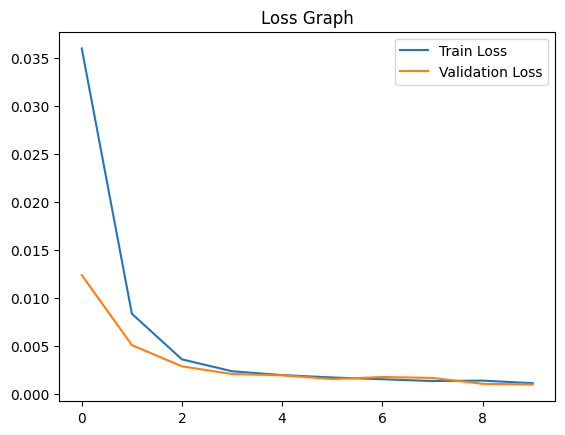

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [12]:
test_loss = model.evaluate(val_ds_ae)
print("Test Loss:", test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0010
Test Loss: 0.001004005316644907
